<a href="https://colab.research.google.com/github/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/blob/main/Color_Map_of_the_World.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Figure size 1800x1000 with 0 Axes>

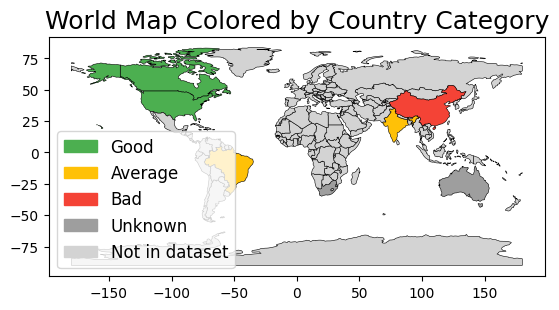

In [ ]:
!pip install geopandas matplotlib requests

import geopandas as gpd
import matplotlib.pyplot as plt
import requests, zipfile, io
import pandas as pd

# ---------------------------------------------------------
# 1. Download Natural Earth shapefile (Admin 0 Countries)
#    Updated working URL
# ---------------------------------------------------------
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("ne_countries")

# Load the shapefile
world = gpd.read_file("ne_countries/ne_110m_admin_0_countries.shp")

# ---------------------------------------------------------
# 2. Example dataset of country categories
# ---------------------------------------------------------
country_categories = {
    "United States of America": "Good",
    "Canada": "Good",
    "Brazil": "Average",
    "India": "Average",
    "China": "Bad",
    "Russian Federation": "Bad",
    "Australia": "Unknown",
    "South Africa": "Unknown"
}

df = pd.DataFrame(list(country_categories.items()), columns=["country", "category"])

# ---------------------------------------------------------
# 3. Merge with world map
# ---------------------------------------------------------
merged = world.merge(df, how="left", left_on="NAME", right_on="country")

# ---------------------------------------------------------
# 4. Define colors
# ---------------------------------------------------------
color_map = {
    "Good": "#4CAF50",
    "Average": "#FFC107",
    "Bad": "#F44336",
    "Unknown": "#9E9E9E"
}

merged["color"] = merged["category"].map(color_map).fillna("#D3D3D3")

# ---------------------------------------------------------
# 5. Plot
# ---------------------------------------------------------
plt.figure(figsize=(18, 10))
merged.plot(color=merged["color"], edgecolor="black", linewidth=0.4)

plt.title("World Map Colored by Country Category", fontsize=18)

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color_map["Good"], label="Good"),
    mpatches.Patch(color=color_map["Average"], label="Average"),
    mpatches.Patch(color=color_map["Bad"], label="Bad"),
    mpatches.Patch(color=color_map["Unknown"], label="Unknown"),
    mpatches.Patch(color="#D3D3D3", label="Not in dataset")
]

plt.legend(handles=legend_patches, loc="lower left", fontsize=12)
plt.show()
